# Diabetes Prediction/Classification using the Pima Indians Diabetes Database

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split

## Start by visualizing how our dataset looks like:

In [2]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print("Shape:", df.shape)
df.info()

# Summary statistics
df.describe()

Shape: (768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


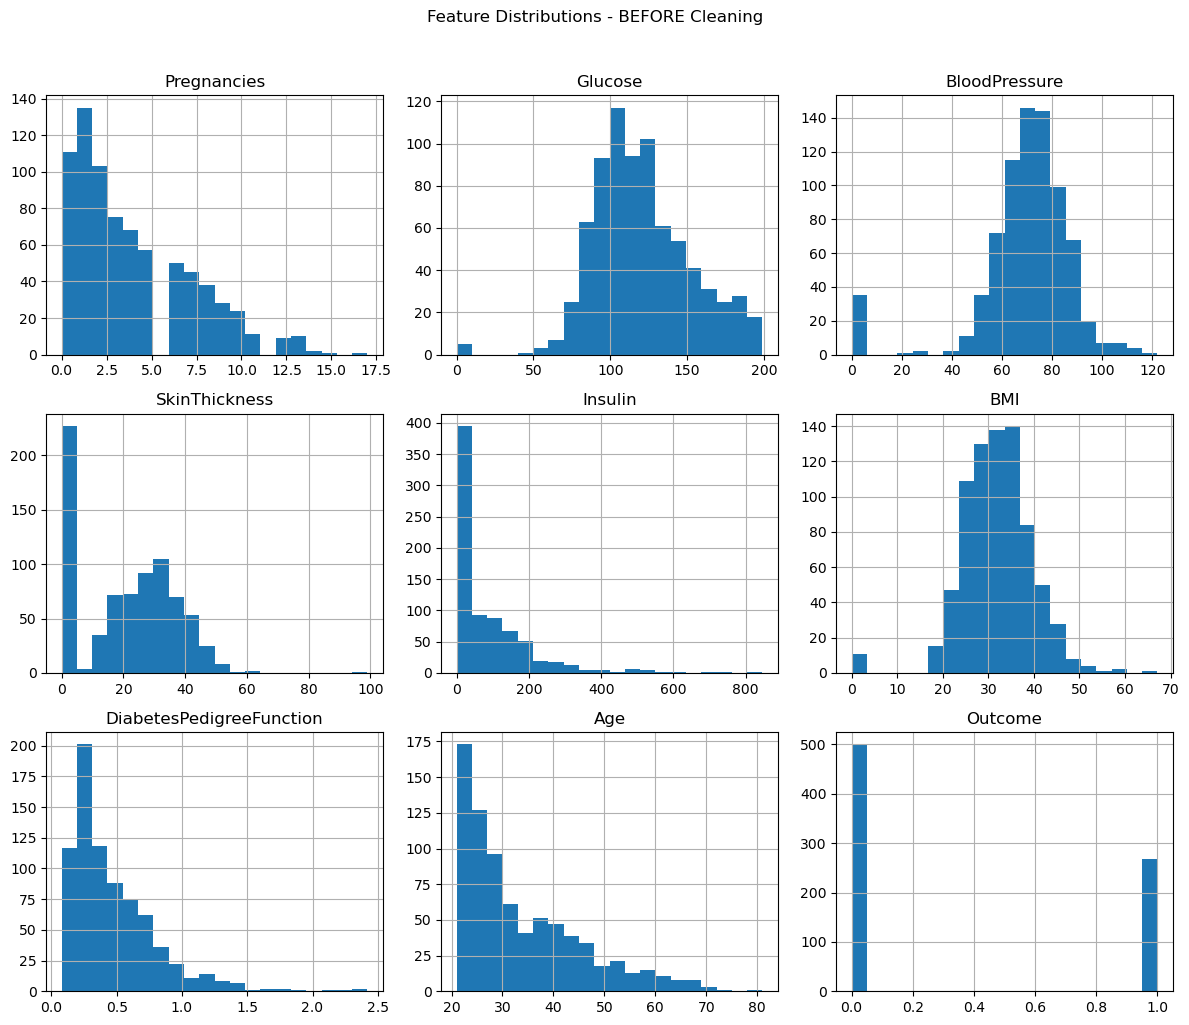

In [4]:
#Visualize raw distributions ( BEFORE cleaning )
df.hist(figsize=(12, 10), bins=20)
plt.suptitle("Feature Distributions - BEFORE Cleaning", y=1.02)
plt.tight_layout()
plt.show()

Zero counts per column:
 Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


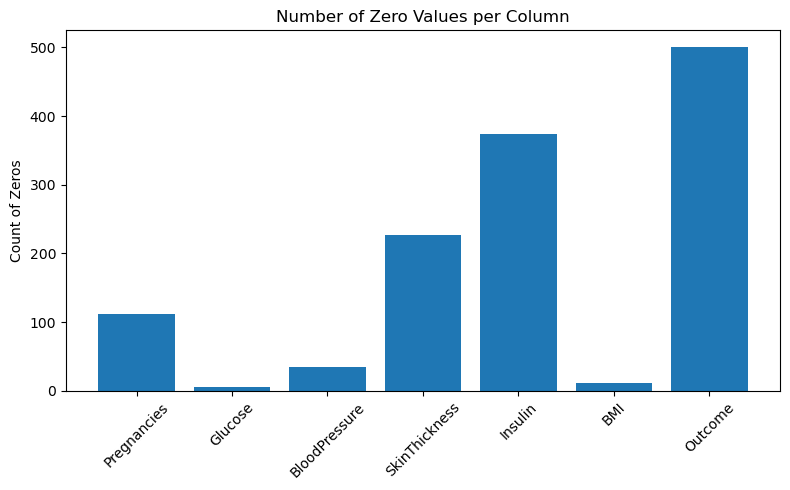

In [5]:
zero_counts = (df == 0).sum()
print("Zero counts per column:\n", zero_counts)
non_zero_cols = zero_counts[zero_counts > 0]

plt.figure(figsize=(8, 5))
plt.bar(non_zero_cols.index, non_zero_cols.values)
plt.title("Number of Zero Values per Column")
plt.ylabel("Count of Zeros")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Note that in certain areas, there are values of zero. This is physiologically impossible, such as a zero in glucose or insulin.

In [6]:
columns_with_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace zeros with NaN
df_clean = df.copy()
df_clean[columns_with_missing] = df_clean[columns_with_missing].replace(0, np.nan)

# Show missing counts
print("\nMissing values per column AFTER converting zeros to NaN:")
print(df_clean.isna().sum())


Missing values per column AFTER converting zeros to NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


### Train–test split BEFORE imputation (to avoid data leakage)

In [7]:
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y 
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nMissing values in X_train BEFORE imputation:")
print(X_train.isna().sum())

print("\nMissing values in X_test BEFORE imputation:")
print(X_test.isna().sum())

X_train shape: (614, 8)
X_test shape: (154, 8)

Missing values in X_train BEFORE imputation:
Pregnancies                   0
Glucose                       4
BloodPressure                23
SkinThickness               175
Insulin                     290
BMI                           9
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

Missing values in X_test BEFORE imputation:
Pregnancies                  0
Glucose                      1
BloodPressure               12
SkinThickness               52
Insulin                     84
BMI                          2
DiabetesPedigreeFunction     0
Age                          0
dtype: int64


### Imputation to be done after the split to prevent data leakage

In [8]:
X_train = X_train.copy()
X_test = X_test.copy()

median_values = X_train[columns_with_missing].median()
print("\nTraining set medians used for imputation:")
print(median_values)

# Fill NaNs in both train and test using training medians
X_train.loc[:, columns_with_missing] = X_train[columns_with_missing].fillna(median_values)
X_test.loc[:, columns_with_missing] = X_test[columns_with_missing].fillna(median_values)

print("\nMissing values in X_train after imputation:")
print(X_train.isna().sum())

print("\nMissing values in X_test after imputation:")
print(X_test.isna().sum())


Training set medians used for imputation:
Glucose          117.0
BloodPressure     72.0
SkinThickness     29.0
Insulin          125.0
BMI               32.4
dtype: float64

Missing values in X_train after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

Missing values in X_test after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


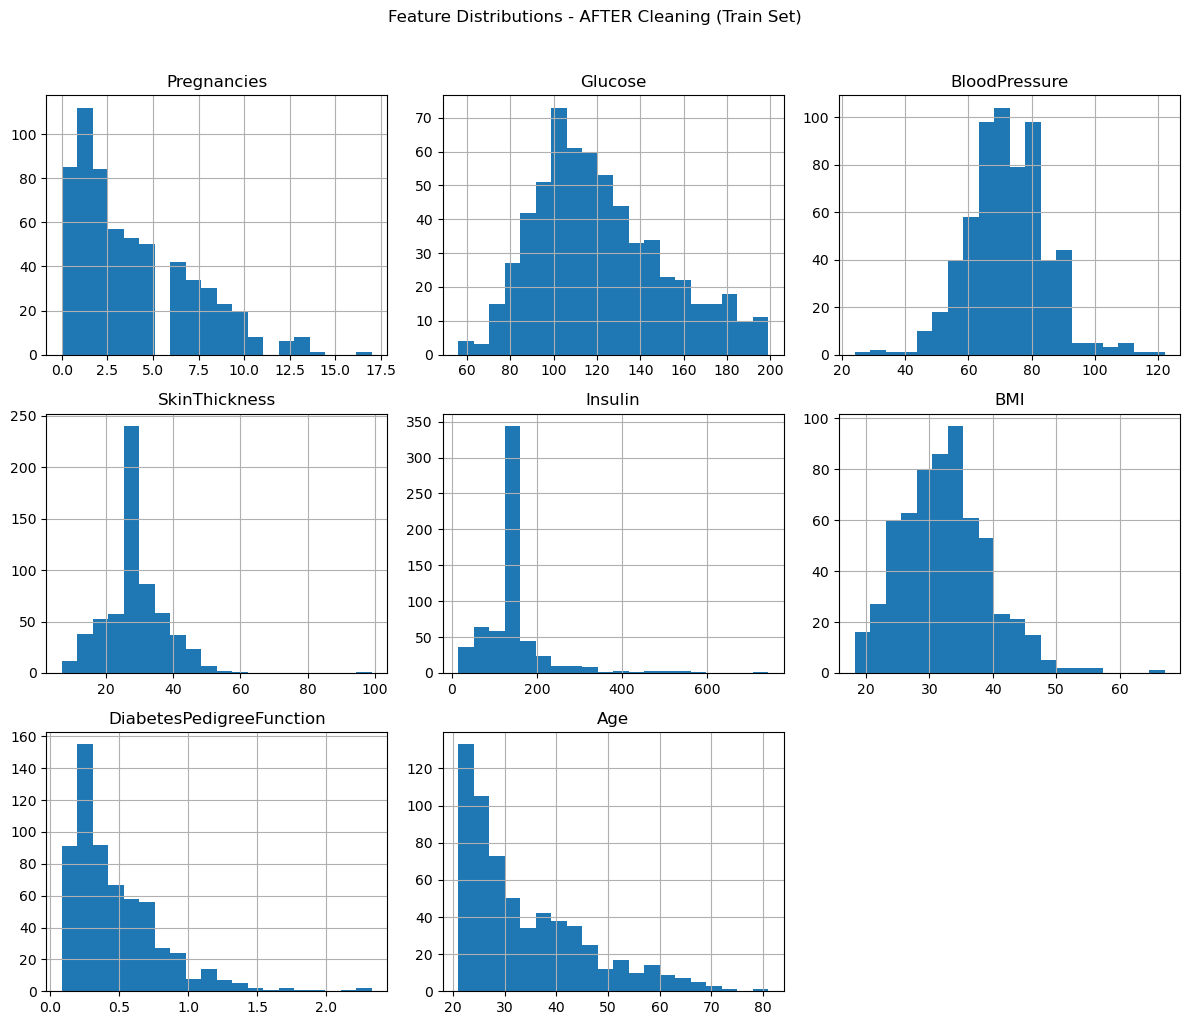

In [9]:
X_train_for_plot = X_train.copy()

X_train_for_plot.hist(figsize=(12, 10), bins=20)
plt.suptitle("Feature Distributions - AFTER Cleaning (Train Set)", y=1.02)
plt.tight_layout()
plt.show()

In [10]:
os.makedirs("processed", exist_ok=True)

X_train.to_csv("processed/X_train_clean.csv", index=False)
X_test.to_csv("processed/X_test_clean.csv", index=False)
y_train.to_csv("processed/y_train_clean.csv", index=False)
y_test.to_csv("processed/y_test_clean.csv", index=False)

print("Saved cleaned train/test splits in 'processed/' folder:")
print("- processed/X_train_clean.csv")
print("- processed/X_test_clean.csv")
print("- processed/y_train_clean.csv")
print("- processed/y_test_clean.csv")

Saved cleaned train/test splits in 'processed/' folder:
- processed/X_train_clean.csv
- processed/X_test_clean.csv
- processed/y_train_clean.csv
- processed/y_test_clean.csv
